<a href="https://colab.research.google.com/github/carloscifuentesingsoft1560-cyber/Learning_Pytorch/blob/main/modelo_de_regresion_lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cpu'

In [2]:
volumen = 0.8
sesgo = 0.2

inicio = 0
final = 1
step = 0.025
X = torch.arange(start=inicio, end=final, step=step).unsqueeze(dim=1)
print(f"Tamaño de X: {X.shape}")
y = volumen * X + sesgo
print(f"Tamaño de y: {y.shape}")

X[:10], y[:10]

Tamaño de X: torch.Size([40, 1])
Tamaño de y: torch.Size([40, 1])


(tensor([[0.0000],
         [0.0250],
         [0.0500],
         [0.0750],
         [0.1000],
         [0.1250],
         [0.1500],
         [0.1750],
         [0.2000],
         [0.2250]]),
 tensor([[0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800]]))

In [5]:
train_division = int(0.7 *len(X))

x_train, y_train = X[:train_division], y[:train_division]
x_test, y_test = X[train_division:], y[train_division:]


In [6]:

len(x_train), len(y_train), len(x_test), len(y_test)

(28, 28, 12, 12)

In [27]:
def plot_predictions(train_data=x_train,
                     train_labels=y_train,
                     test_data=x_test,
                     test_labels=y_test,
                     predictions=None):
  plt.figure(figsize=(10, 10))
  plt.scatter(train_data, train_labels, color="g",s=4, label="Datos de entrenamiento")
  plt.scatter(test_data, test_labels, c="y", s=4, label="Datos de prueba")

  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=6, label="Predicciones")
    plt.legend(prop={"size": 12});




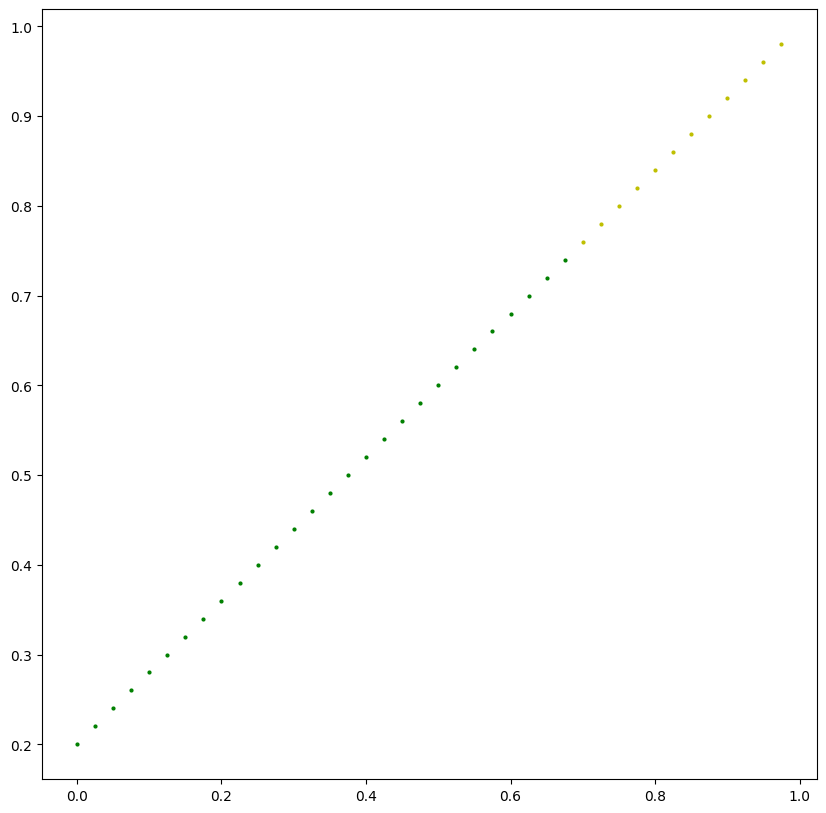

In [28]:
plot_predictions()

In [29]:
class ModeloRegresionLineal(nn.Module):
  def __init__(self) :
    super().__init__()
    self.volumen = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)
    self.sesgo = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

  def forward(self,x:torch.Tensor) -> torch.Tensor:
    return self.volumen * x + self.sesgo

In [30]:
torch.manual_seed(42)

model_1 = ModeloRegresionLineal()


In [31]:
model_1

ModeloRegresionLineal()

In [32]:
model_1.state_dict()

OrderedDict([('volumen', tensor([0.3367])), ('sesgo', tensor([0.1288]))])

In [33]:
with torch.inference_mode():
  y_testc = model_1(x_test)

In [34]:
y_testc

tensor([[0.3645],
        [0.3729],
        [0.3813],
        [0.3897],
        [0.3982],
        [0.4066],
        [0.4150],
        [0.4234],
        [0.4318],
        [0.4402],
        [0.4487],
        [0.4571]])

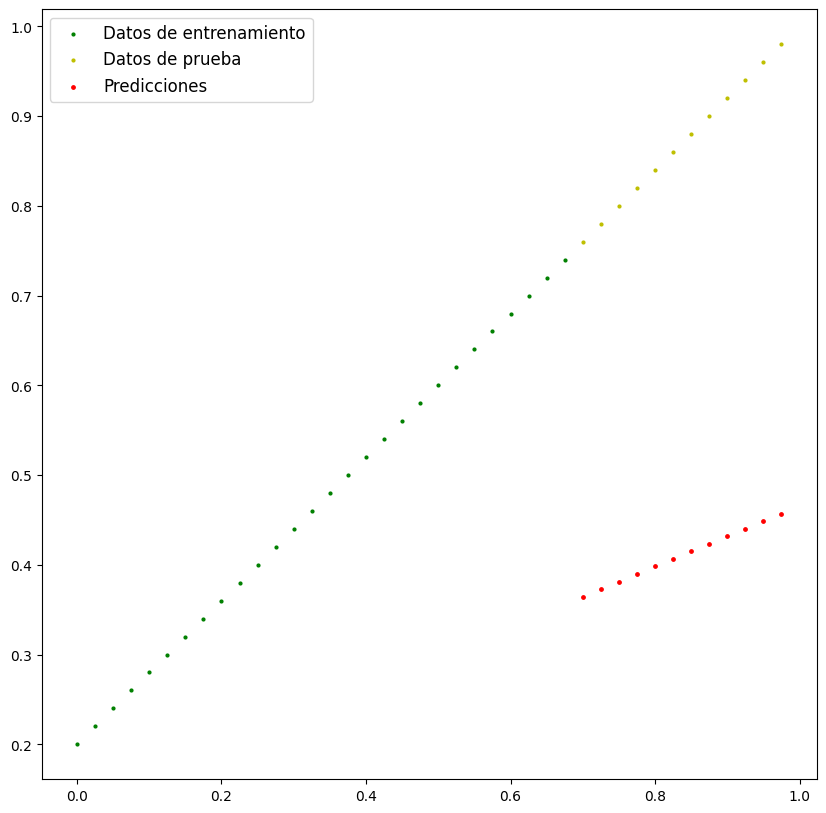

In [35]:
plot_predictions(predictions= y_testc)